# Trabalho Prático 03 - MLPClassifier
## GCC 128 - Inteligência Artificial

Aplicação de redes neurais perceptron multicamadas para classificação das bases Iris e Wine, com comparação com o KNN estudado no Trabalho Prático 01.

**Professor:** Ahmed Ali Abdalla Esmin  
**Integrantes:** Anderson Fernandes Barbosa e João Pedro Brites  


## Objetivos

- Treinar um `MLPClassifier` do scikit-learn nas bases Iris e Wine.
- Apresentar matrizes de confusão, precisão, revocação e acurácia.
- Comparar os resultados com um KNN de 5 vizinhos, usando os mesmos dados de teste.
- Interpretar o comportamento e as limitações dos modelos.

## Introdução

O MLP (Multi-Layer Perceptron) é uma rede neural feed-forward formada por camadas de neurônios conectadas. Durante o treinamento, os pesos são ajustados para reduzir o erro entre as classes reais e as previstas. Neste trabalho usamos a implementação `MLPClassifier` do scikit-learn; a biblioteca executa a otimização, enquanto a preparação, avaliação e análise dos dados são explicitadas neste notebook.

A base Iris contém 150 amostras, quatro atributos e três espécies. A base Wine contém 178 amostras, 13 atributos físico-químicos e três classes de vinho. Como os atributos têm escalas diferentes, ambos os classificadores são colocados em pipelines com `StandardScaler`. O scaler é ajustado somente nos dados de treino, evitando vazamento de informação.

## Metodologia

Para cada base, será usado um particionamento estratificado de 70% para treino e 30% para teste, com `random_state=42`. KNN e MLP recebem exatamente os mesmos exemplos em cada partição. O KNN usa `k=5`, valor que teve melhor acurácia entre os valores testados no TP01. No notebook anterior, a versão sem padronização obteve na Iris acurácia de 0,9778, precisão macro de 0,9792 e revocação macro de 0,9778; aqui também apresentamos uma comparação controlada com KNN padronizado.

Precisão e revocação são calculadas pela média macro, isto é, calculadas separadamente por classe e depois promediadas com o mesmo peso. A acurácia representa a proporção total de previsões corretas. As matrizes de confusão usam linhas para as classes reais e colunas para as classes previstas.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
TEST_SIZE = 0.30
K_VIZINHOS = 5

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 1. Bases de dados

As duas bases são carregadas diretamente do scikit-learn. Os rótulos são conhecidos e participam do treinamento supervisionado. A exploração inicial abaixo confirma a quantidade de amostras, atributos, classes e eventuais valores ausentes.

In [3]:
bases = {
    'Iris': load_iris(as_frame=True),
    'Wine': load_wine(as_frame=True),
}

for nome, base in bases.items():
    X = base.data
    y = base.target
    print(f'\n{nome}')
    print(f'Amostras: {X.shape[0]} | Atributos: {X.shape[1]} | Classes: {len(base.target_names)}')
    print(f'Valores ausentes: {X.isna().sum().sum()}')
    print('Classes:', list(base.target_names))
    display(X.head(3))


Iris
Amostras: 150 | Atributos: 4 | Classes: 3
Valores ausentes: 0
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2



Wine
Amostras: 178 | Atributos: 13 | Classes: 3
Valores ausentes: 0
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


## 2. Preparação e definição dos classificadores

O `StandardScaler` centraliza e escala cada atributo. Ele está dentro do pipeline para que, durante o `fit`, seja ajustado somente com os dados de treino. A transformação aprendida é então aplicada ao teste.

O KNN é incluído como referência do TP01, com cinco vizinhos. O MLP possui uma camada oculta com 10 neurônios e ativação ReLU. O `random_state` torna a inicialização reproduzível; o limite de iterações permite que o otimizador tenha tempo suficiente para convergir.

In [4]:
particoes = {}
resultados = []
previsoes_por_base = {}
matrizes = {}

for nome, base in bases.items():
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        base.data,
        base.target,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=base.target,
    )
    particoes[nome] = (X_treino, X_teste, y_treino, y_teste)
    print(f'{nome}: treino={len(X_treino)}, teste={len(X_teste)}')

modelos = {
    'KNN (k=5)': lambda: make_pipeline(
        StandardScaler(), KNeighborsClassifier(n_neighbors=K_VIZINHOS)
    ),
    'MLPClassifier': lambda: make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(10,),
            activation='relu',
            solver='adam',
            max_iter=2000,
            n_iter_no_change=30,
            random_state=RANDOM_STATE,
        ),
    ),
}

print('Particionamentos e modelos preparados.')

Iris: treino=105, teste=45
Wine: treino=124, teste=54
Particionamentos e modelos preparados.


## 3. Treinamento e avaliação

Para cada combinação de base e modelo, medimos separadamente o tempo de treinamento e o de predição. Em seguida, calculamos acurácia, precisão macro e revocação macro. A matriz de confusão e o relatório por classe ajudam a localizar erros que uma métrica agregada pode esconder.

In [6]:
for nome_base, base in bases.items():
    X_treino, X_teste, y_treino, y_teste = particoes[nome_base]
    previsoes_por_base[nome_base] = {}
    matrizes[nome_base] = {}

    for nome_modelo, criar_modelo in modelos.items():
        modelo = criar_modelo()
        inicio_treino = time.perf_counter()
        with warnings.catch_warnings(record=True) as avisos:
            warnings.simplefilter('always', ConvergenceWarning)
            modelo.fit(X_treino, y_treino)
        tempo_treino = time.perf_counter() - inicio_treino

        inicio_predicao = time.perf_counter()
        previsoes = modelo.predict(X_teste)
        tempo_predicao = time.perf_counter() - inicio_predicao
        cm = confusion_matrix(y_teste, previsoes, labels=range(len(base.target_names)))

        previsoes_por_base[nome_base][nome_modelo] = previsoes
        matrizes[nome_base][nome_modelo] = cm
        resultados.append({
            'Base': nome_base,
            'Modelo': nome_modelo,
            'Acurácia': accuracy_score(y_teste, previsoes),
            'Precisão (macro)': precision_score(y_teste, previsoes, average='macro', zero_division=0),
            'Revocação (macro)': recall_score(y_teste, previsoes, average='macro', zero_division=0),
            'Tempo de treino (s)': tempo_treino,
            'Tempo de predição (s)': tempo_predicao,
            'Iterações MLP': modelo[-1].n_iter_ if nome_modelo == 'MLPClassifier' else None,
            'Convergência MLP': not any(issubclass(aviso.category, ConvergenceWarning) for aviso in avisos) if nome_modelo == 'MLPClassifier' else None,
        })

        print(f'\n{nome_base} - {nome_modelo}')
        print(f'Acurácia: {accuracy_score(y_teste, previsoes):.4f}')
        print(f'Precisão (macro): {precision_score(y_teste, previsoes, average="macro", zero_division=0):.4f}')
        print(f'Revocação (macro): {recall_score(y_teste, previsoes, average="macro", zero_division=0):.4f}')
        print(f'Tempo de treinamento: {tempo_treino:.6f} s | tempo de predição: {tempo_predicao:.6f} s')
        if nome_modelo == 'MLPClassifier':
            print(f'Iterações: {modelo[-1].n_iter_} | convergiu: {not any(issubclass(aviso.category, ConvergenceWarning) for aviso in avisos)}')
        print('Matriz de confusão (linhas = reais; colunas = previstas):')
        print(cm)


Iris - KNN (k=5)
Acurácia: 0.9111
Precisão (macro): 0.9298
Revocação (macro): 0.9111
Tempo de treinamento: 0.009237 s | tempo de predição: 0.005863 s
Matriz de confusão (linhas = reais; colunas = previstas):
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

Iris - MLPClassifier
Acurácia: 0.9556
Precisão (macro): 0.9556
Revocação (macro): 0.9556
Tempo de treinamento: 0.830811 s | tempo de predição: 0.002898 s
Iterações: 1060 | convergiu: True
Matriz de confusão (linhas = reais; colunas = previstas):
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]

Wine - KNN (k=5)
Acurácia: 0.9444
Precisão (macro): 0.9444
Revocação (macro): 0.9524
Tempo de treinamento: 0.006726 s | tempo de predição: 0.005314 s
Matriz de confusão (linhas = reais; colunas = previstas):
[[18  0  0]
 [ 0 18  3]
 [ 0  0 15]]

Wine - MLPClassifier
Acurácia: 1.0000
Precisão (macro): 1.0000
Revocação (macro): 1.0000
Tempo de treinamento: 0.478083 s | tempo de predição: 0.003040 s
Iterações: 634 | convergiu: True
Matriz de confusão (linhas = reais; 

## 4. Matrizes de confusão

Cada painel corresponde a uma base e um modelo. A diagonal principal representa as previsões corretas; os valores fora dela mostram quais classes foram confundidas.

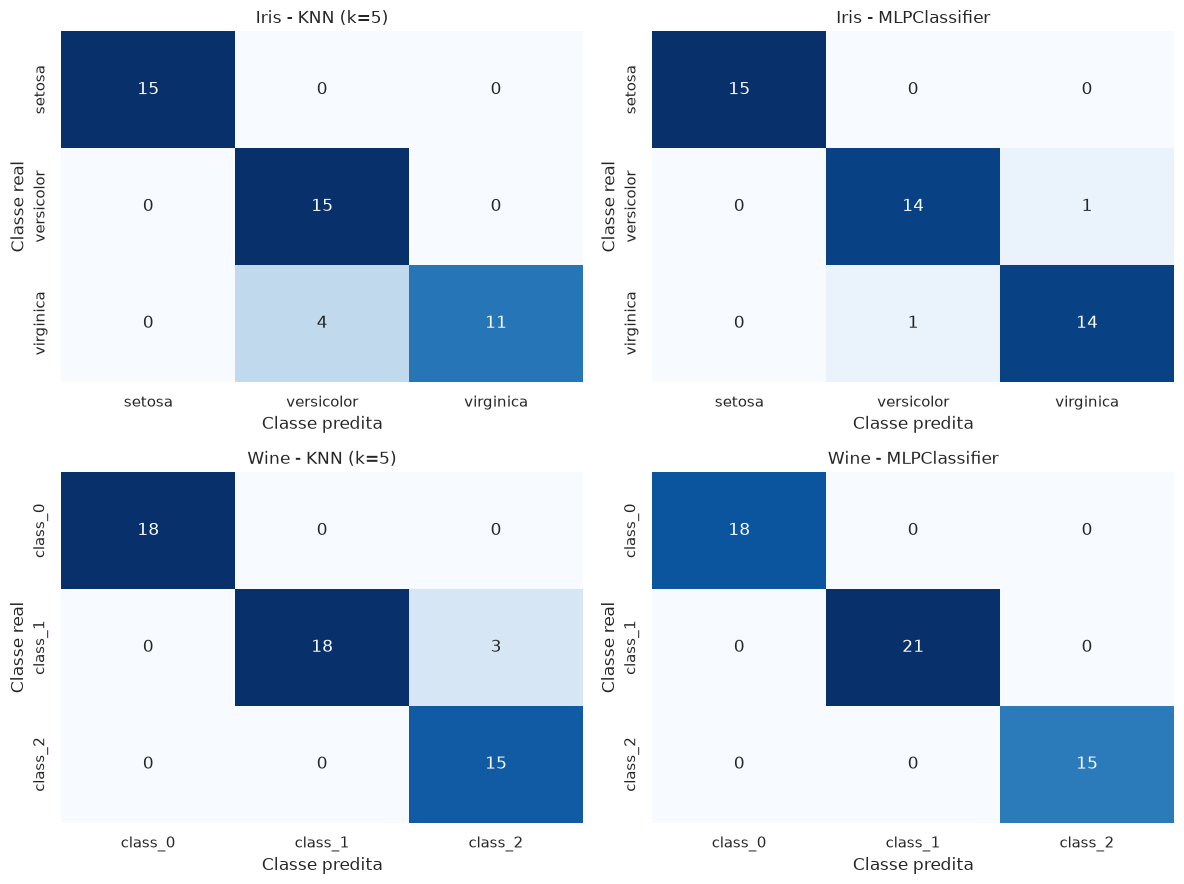

In [7]:
fig, eixos = plt.subplots(2, 2, figsize=(12, 9))

for linha, nome_base in enumerate(bases):
    nomes_classes = bases[nome_base].target_names
    for coluna, nome_modelo in enumerate(modelos):
        sns.heatmap(
            matrizes[nome_base][nome_modelo],
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=nomes_classes,
            yticklabels=nomes_classes,
            ax=eixos[linha, coluna],
        )
        eixos[linha, coluna].set_title(f'{nome_base} - {nome_modelo}')
        eixos[linha, coluna].set_xlabel('Classe predita')
        eixos[linha, coluna].set_ylabel('Classe real')

plt.tight_layout()
plt.show()

## 5. Comparação entre KNN e MLPClassifier

A tabela consolida as métricas dos dois modelos. A avaliação é feita sobre os mesmos exemplos de teste e com padronização dentro do pipeline. O KNN não tem uma etapa iterativa de otimização, enquanto o MLP aprende pesos e pode exigir mais tempo de treinamento. Os tempos variam conforme o computador e não devem ser interpretados como uma medida universal.

In [8]:
tabela_resultados = pd.DataFrame(resultados)
display(tabela_resultados.round(4))

for nome_base in bases:
    comparacao_base = tabela_resultados[tabela_resultados['Base'] == nome_base].set_index('Modelo')
    melhor_modelo = comparacao_base['Acurácia'].idxmax()
    diferenca = comparacao_base.loc['MLPClassifier', 'Acurácia'] - comparacao_base.loc['KNN (k=5)', 'Acurácia']
    if diferenca > 0:
        conclusao = f'MLPClassifier teve acurácia maior por {diferenca:.4f}.'
    elif diferenca < 0:
        conclusao = f'KNN teve acurácia maior por {abs(diferenca):.4f}.'
    else:
        conclusao = 'Os modelos tiveram a mesma acurácia.'
    print(f'{nome_base}: melhor acurácia neste split = {melhor_modelo}. {conclusao}')

print('Referência TP01 (Iris, KNN manual, k=5, sem padronização): acurácia=0.9778, precisão macro=0.9792, revocação macro=0.9778.')
print('A comparação acima padroniza o KNN; pequenas diferenças em relação ao TP01 decorrem da transformação dos atributos e da implementação usada.')

,Base,Modelo,Acurácia,Precisão (macro),Revocação (macro),Tempo de treino (s),Tempo de predição (s),Iterações MLP,Convergência MLP
0,Iris,KNN (k=5),0.9111,0.9298,0.9111,0.0092,0.0059,NaN,None
1,Iris,MLPClassifier,0.9556,0.9556,0.9556,0.8308,0.0029,1060.0,True
2,Wine,KNN (k=5),0.9444,0.9444,0.9524,0.0067,0.0053,NaN,None
3,Wine,MLPClassifier,1.0000,1.0000,1.0000,0.4781,0.0030,634.0,True


Iris: melhor acurácia neste split = MLPClassifier. MLPClassifier teve acurácia maior por 0.0444.
Wine: melhor acurácia neste split = MLPClassifier. MLPClassifier teve acurácia maior por 0.0556.
Referência TP01 (Iris, KNN manual, k=5, sem padronização): acurácia=0.9778, precisão macro=0.9792, revocação macro=0.9778.
A comparação acima padroniza o KNN; pequenas diferenças em relação ao TP01 decorrem da transformação dos atributos e da implementação usada.


## 6. Análise e discussão

As métricas devem ser analisadas em conjunto. A acurácia resume os acertos totais, enquanto precisão e revocação macro dão peso igual a cada classe. A matriz de confusão mostra que, na Iris, o MLP errou duas amostras (uma versicolor e uma virginica), enquanto o KNN padronizado errou quatro, todas virginica previstas como versicolor. Na Wine, o MLP acertou as 54 amostras de teste; o KNN confundiu três amostras da classe 1 com a classe 2.

Na comparação controlada deste notebook, o MLP teve acurácia de 0,9556 na Iris, contra 0,9111 do KNN padronizado, e 1,0000 na Wine, contra 0,9444 do KNN padronizado. O MLP convergiu nas duas bases. Seu treinamento foi mais demorado neste ambiente, enquanto a predição teve duração da mesma ordem de grandeza. Os tempos dependem do computador e do estado do ambiente.

No TP01, porém, a Iris foi avaliada com KNN sem padronização e `k=5`, alcançando acurácia de 0,9778, precisão macro de 0,9792 e revocação macro de 0,9778. Esse resultado supera os 0,9556 do MLP nesta partição. Assim, o MLP venceu a comparação com KNN padronizado, mas não superou a referência original do TP01 na Iris. O efeito da escala altera a comparação, e nenhum desses resultados isolados demonstra superioridade geral.

O KNN classifica uma amostra pela proximidade de exemplos do treino. É simples, mas depende da escala e da escolha de `k`; sua etapa de predição pode se tornar custosa em bases maiores. O MLP aprende uma fronteira de decisão por meio dos pesos da rede e pode representar relações não lineares, mas seu resultado depende da arquitetura, inicialização, parâmetros de otimização e convergência. Em bases pequenas, uma arquitetura maior não garante generalização melhor.

### Conclusão

O MLPClassifier foi aplicado corretamente às bases Iris e Wine, com padronização ajustada somente nos dados de treino, avaliação por acurácia, precisão e revocação macro, e matrizes de confusão por classe. Na partição utilizada, o MLP obteve melhor resultado que o KNN padronizado nas duas bases e acertou todas as amostras de teste da Wine. Na comparação direta com o KNN sem padronização do TP01, o KNN teve maior acurácia na Iris. A escolha depende, portanto, do conjunto de dados, da escala das variáveis e dos parâmetros: para uma conclusão mais ampla, seria necessário usar validação cruzada e testar outras configurações.

## Vídeo de apresentação

Inserir o link do vídeo antes da entrega: `COLE_AQUI_O_LINK_DO_VIDEO`.

## Referências

- Documentação do scikit-learn: `MLPClassifier`, `KNeighborsClassifier`, `StandardScaler` e métricas de classificação.
- Trabalho Prático 01 - Implementação e comparação de KNN na base Iris.